# M2 Deep Learning Coursework

Harvey Bermingham

In [1]:
#importing os
import os
import random

#initialising a global seed (reproducibility; instructions CPU-only)
GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED) #setting Python's initialisation seed
os.environ['CUDA_VISIBLE_DEVICES'] = "-1" #avoiding use of any NVIDIA GPUs

#importing general packages
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import optuna


def set_seed(seed: int) -> None:
    """Reset Python, NumPy, and PyTorch RNGs (coursework: avoid nondeterminism where possible)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(GLOBAL_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


/Users/harvey/Documents/Cambridge/M2/Coursework/hb747/m2_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Preprocessing and Data Exploration

Before any modelling, some data exploration is applied to the three datasets, they are loaded and then inspected for missing values, duplicates, and class imbalance. Feature distributions are then checked visually. Train-fit z-score standardisation is applied so that the model always receives zero mean and unit variance inputs. Importantly, the same mean and standard deviation computed on the training set are used to transform validation and test splits.

In [2]:
# Load data
DATA_DIR = Path("data")
train_df = pd.read_csv(DATA_DIR / "moons_train.csv")
val_df = pd.read_csv(DATA_DIR / "moons_val.csv")
test_df = pd.read_csv(DATA_DIR / "moons_test.csv")


Exploring the layout of the datasets and defining their structure.

In [3]:
# Structure: shape, columns, dtypes
expected = {"train": 800, "val": 100, "test": 100}
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:<5s}  shape={str(df.shape):<10s}  columns={list(df.columns)}")
print("\ndtypes (all datasets identical):\n", train_df.dtypes)

train  shape=(800, 3)    columns=['x1', 'x2', 'class']
val    shape=(100, 3)    columns=['x1', 'x2', 'class']
test   shape=(100, 3)    columns=['x1', 'x2', 'class']

dtypes (all datasets identical):
 x1       float64
x2       float64
class      int64
dtype: object


The shape of each of the classes, column names and the dtypes appear as expected from the coursework outline.

**Missing values and duplicates**

In [4]:
# Missing values and duplicates
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    nan_x1 = df["x1"].isna().sum()
    nan_x2 = df["x2"].isna().sum()
    dup = df.duplicated(subset=["x1", "x2"]).sum()
    print(f"{name:<5s}  NaNs x1={nan_x1}  x2={nan_x2}  duplicates={dup}")

train  NaNs x1=0  x2=0  duplicates=0
val    NaNs x1=0  x2=0  duplicates=0
test   NaNs x1=0  x2=0  duplicates=0


No missing values or duplicates have been found in any of the provided datasets.

**Tensors and data as input**

In [5]:
# Raw feature tensors
x_train_raw = torch.from_numpy(train_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_val_raw = torch.from_numpy(val_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_test_raw = torch.from_numpy(test_df[["x1", "x2"]].to_numpy(dtype=np.float32))

# Train-only standardisation (best practice): fit on train, apply to all splits
feature_mean = x_train_raw.mean(dim=0, keepdim=True)
feature_std = x_train_raw.std(dim=0, keepdim=True).clamp_min(1e-8)
x_train = (x_train_raw - feature_mean) / feature_std
x_val = (x_val_raw - feature_mean) / feature_std
x_test = (x_test_raw - feature_mean) / feature_std
class_train = train_df["class"].values
class_val = val_df["class"].values
class_test = test_df["class"].values

print()
for name, t in [("x_train_raw", x_train_raw), ("x_val_raw", x_val_raw), ("x_test_raw", x_test_raw)]:
    mu = t.mean(dim=0)
    sd = t.std(dim=0).clamp_min(1e-8)
    print(f"{name:<11s} shape={str(tuple(t.shape)):<10s} dtype={str(t.dtype):<14s} min={t.min().item():>8.4f} max={t.max().item():>8.4f}")
    print(f"{'':<11s} mean=[{mu[0].item():>8.4f}, {mu[1].item():>8.4f}] std=[{sd[0].item():>8.4f}, {sd[1].item():>8.4f}]")

print()
for name, t in [("x_train_std", x_train), ("x_val_std", x_val), ("x_test_std", x_test)]:
    print(f"{name:<7s}  shape={str(tuple(t.shape)):<10s}  dtype={str(t.dtype):<14s}  min={t.min().item():>8.4f}  max={t.max().item():>8.4f}")


x_train_raw shape=(800, 2)   dtype=torch.float32  min= -1.1268 max=  2.0669
            mean=[  0.5210,   0.2313] std=[  0.8748,   0.4910]
x_val_raw   shape=(100, 2)   dtype=torch.float32  min= -1.0031 max=  2.0290
            mean=[  0.4606,   0.3343] std=[  0.7998,   0.5437]
x_test_raw  shape=(100, 2)   dtype=torch.float32  min= -1.0391 max=  2.0557
            mean=[  0.3662,   0.3227] std=[  0.8638,   0.5010]

x_train_std  shape=(800, 2)    dtype=torch.float32   min= -1.8837  max=  1.9747
x_val_std  shape=(100, 2)    dtype=torch.float32   min= -1.7423  max=  1.7245
x_test_std  shape=(100, 2)    dtype=torch.float32   min= -1.7834  max=  1.7543


All three datasets contain the expected sample counts (800 / 100 / 100) with columns x1, x2, and class. No missing values or duplicates appear in any split. The training features span roughly [−1.13, 2.07], with all having postive means just under 0.5 in both dimensions. Despite this each of the datasets were normalised according to the original raw training dataset to stay in line with best practices.

**Class Distributions** 

The following graphs aim to explore class structure, spatial distribution of the normalised features and consistency across the class splits.

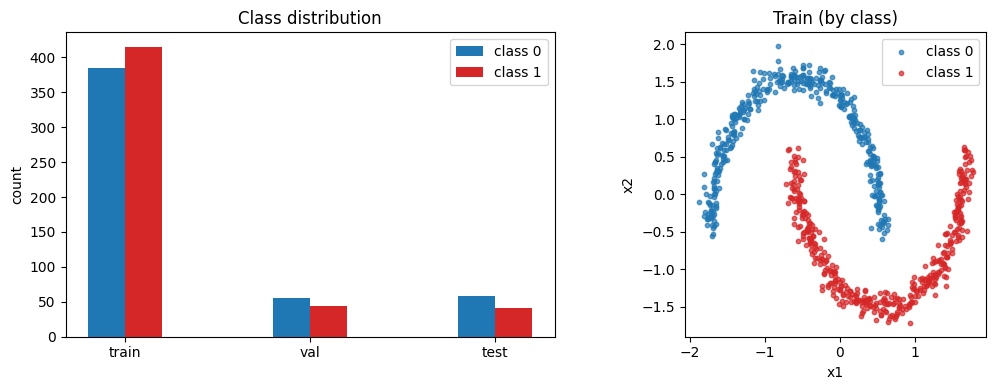

In [6]:
# Figure 1: Class distribution + Train (by class) scatter
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
splits = [("train", train_df), ("val", val_df), ("test", test_df)]
cnt = np.array([[(df["class"] == 0).sum(), (df["class"] == 1).sum()] for _, df in splits])
x, w = np.arange(3), 0.2
axes[0].bar(x - w/2, cnt[:, 0], w, label="class 0", color="#1f77b4")
axes[0].bar(x + w/2, cnt[:, 1], w, label="class 1", color="#d62728")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["train", "val", "test"])
axes[0].set_ylabel("count")
axes[0].set_title("Class distribution")
axes[0].legend()
X = x_train.numpy()
axes[1].scatter(X[class_train == 0, 0], X[class_train == 0, 1], c="#1f77b4", label="class 0", alpha=0.7, s=10)
axes[1].scatter(X[class_train == 1, 0], X[class_train == 1, 1], c="#d62728", label="class 1", alpha=0.7, s=10)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Train (by class)")
axes[1].legend()
axes[1].set_aspect("equal")
plt.tight_layout()
fig.savefig("figs_my/class_and_train_scatter.png")
plt.show()

The class distribution bar chart on the left shows small class imbalances across each of the datasets, none of which are considerable or should have an effect on training. The training dataset has around 400 samples per class whereas validation and test splits sit around 50 samples per class. The scatter plot shows the two classes in the training dataset create two disctinct overlapping moons which are non-linearly separable. The raw feature scales were already close to standard normal, but normalisation was applied to all datasets so that the model always receives perfectly standardised inputs across train, validation, and test. 

**General Data Distribution and Density**

Below on the left-hand side a scatter plot of the normalised datasets is plotted, and on the right a density plot of the training dataset.

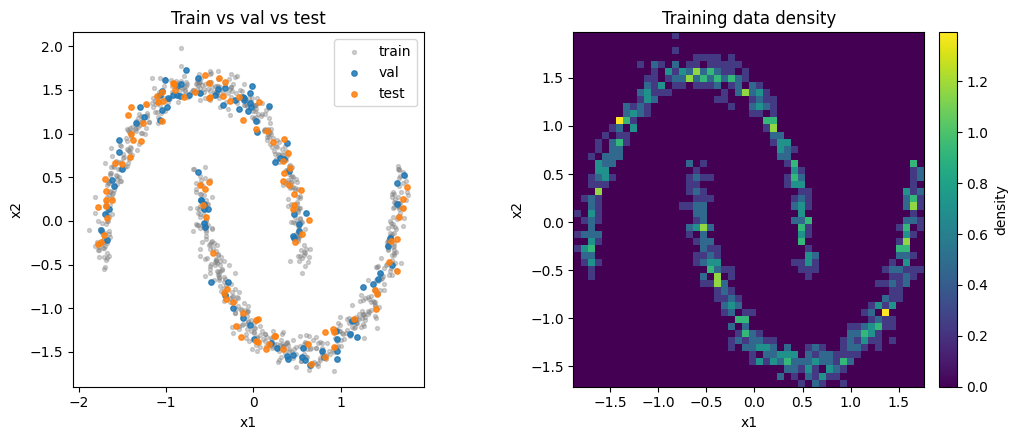

In [7]:
# Figure 2: Train vs val vs test + Training density
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(x_train[:, 0], x_train[:, 1], c="gray", alpha=0.35, s=8, label="train")
axes[0].scatter(x_val[:, 0], x_val[:, 1], alpha=0.85, s=15, label="val")
axes[0].scatter(x_test[:, 0], x_test[:, 1], alpha=0.85, s=15, label="test")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Train vs val vs test")
axes[0].legend()
axes[0].set_aspect("equal")
xt, yt = x_train[:, 0].numpy(), x_train[:, 1].numpy()
H_2d, xe, ye = np.histogram2d(xt, yt, bins=50)
H_2d = H_2d / (H_2d.sum() * (xe[1] - xe[0]) * (ye[1] - ye[0]))
pc = axes[1].pcolormesh(xe, ye, H_2d.T, shading="auto", cmap="viridis")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Training data density")
axes[1].set_aspect("equal")
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(pc, cax=cax, label="density")
plt.tight_layout()
fig.savefig("figs_my/overlay_and_density.png")
plt.show()

The overlay on the left plot shows train, validation, and test points occupying the same region of feature space with no visible distribution shift between the classes, suggesting a model trained on training should be effective at predicting on validation and test. The density plot shows nearly all of the probability mass is concentrated well within the outlines of the two moons. Peak density reaches approximately 3.0, while the density in the area outside of the moons sits close to zero. This regularity in the data should help the main train well as normalising flows are designed to be able to learn to predict between non linearly separable classes.

## 1. A Mini Normalising Flow

### 1) (a) 

A single affine coupling layer is implemented below. It keeps one component of the 2D input fixed and transforms the other via scale and shift parameters that will be produced by training a small network late on (`Linear(1 → H) → ReLU → Linear(H → 2)`, split into `s` and `t`). The scale output is bounded with `tanh` for numerical stability. Both the forward map (base → data) and inverse map (data → base) are provided, each returning the transformed output and the log-determinant of the Jacobian.

In [8]:
# Single MLP: Linear(D→H) → ReLU → Linear(H→2D), then split into s and t. Spec: D=1 here.
class STNet(nn.Module):
    """Scale/shift network used inside a 2D affine coupling layer.

    Given the fixed dimension (shape (B, 1)), this MLP outputs coupling parameters
    
    (s, t)
    (each shape (B, 1)) for transforming the other dimension.

    Notes:
    - The scale output is bounded with `tanh` for numerical stability.
    """

    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, h_fixed):
        """Compute coupling parameters.

        Args:
            h_fixed: Tensor of shape (B, 1).

        Returns:
            s: Tensor of shape (B, 1), bounded via `tanh`.
            t: Tensor of shape (B, 1).
        """
        st = self.net(h_fixed)
        s, t = st.chunk(2, dim=-1)
        s = torch.tanh(s)
        return s, t


# Affine coupling: always fix dim 0 and transform dim 1.
class AffineCoupling2D(nn.Module):
    """RealNVP-style affine coupling transform for 2D vectors.

    Dimension 0 is kept fixed and dimension 1 is affine-transformed using parameters
    produced by `STNet`. The transform returns the output and the corresponding
    log-determinant of the Jacobian.
    """

    def __init__(self, hidden=64):
        super().__init__()
        self.st_net = STNet(hidden=hidden)

    def forward(self, z):
        """Forward map (base z -> data x).

        Args:
            z: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_f(z)|.
        """
        fixed, trans = z[:, :1], z[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, trans * scale + t], dim=-1)
        log_det = s.squeeze(-1)
        return out, log_det

    def inverse(self, x):
        """Inverse map (data x -> base z).

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            z: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_{f^{-1}}(x)|.
        """
        fixed, trans = x[:, :1], x[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, (trans - t) / scale], dim=-1)
        log_det = -s.squeeze(-1)
        return out, log_det

Before stacking layers, a few quick sanity checks are run on the single coupling layer. The first verifies that tensor shapes are preserved through both the forward and inverse maps.

In [9]:
layer = AffineCoupling2D(hidden=64)
z = torch.randn(10,2)
x, log_det_f = layer(z)
z_recon, log_det_inv = layer.inverse(x)

print(z.shape, x.shape, log_det_f.shape, log_det_inv.shape)

torch.Size([10, 2]) torch.Size([10, 2]) torch.Size([10]) torch.Size([10])


Next, the layer's invertibility is checked by passing random inputs through the forward map and then back through the inverse, reporting the maximum reconstruction error.

In [10]:
max_err = (z - z_recon).abs().max().item()
print("max reconstruction error (single layer):", max_err)

max reconstruction error (single layer): 5.960464477539063e-08


Finally, the forward and inverse log-determinants are compared element-wise. For a correct implementation their sum should be zero, since one direction's Jacobian is the inverse of the other's.

In [11]:
print("forward log_det:", {log_det_f[:5]})
print("inverse log_det:", log_det_inv[:5])
print("sum:", (log_det_f + log_det_inv)[:5])

forward log_det: {tensor([0.3085, 0.3081, 0.1313, 0.0577, 0.2967], grad_fn=<SliceBackward0>)}
inverse log_det: tensor([-0.3085, -0.3081, -0.1313, -0.0577, -0.2967], grad_fn=<SliceBackward0>)
sum: tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)


The single-layer tests were consistent with the expected coupling-layer behaviour. 
The shape check returned (10, 2) for both the forward and the inverse outputs, with log-determinant 
vectors of length 10, confirming that tensor dimensions propograte correctly through the flow in both 
directions.

The invertibility test gave a maximum reconstruction error of 5.96e-08, 
which is at the level of float32 numerical precision for this operation. The log-determinant sign 
test also matched theory: forward and inverse values were equal in magnitude with opposite signs, 
and each of their elements sum to zero.

Overall, these checks suggest the 2D affine coupling layer was implemented correctly 
as an invertible change of variables.

### 1) (b)

The full flow is built by stacking $K$ coupling layers with alternating permutations so that each dimension is transformed in turn. The `Permute2D` module swaps the two coordinates between coupling layers; its Jacobian determinant is 1, so the log-determinant contribution is zero. The resulting `Flow2D` class chains forward and inverse passes through all layers and accumulates the total log-determinant.

In [12]:
class Permute2D(nn.Module):
    """Swap the two dimensions.

    This is used between coupling layers so that alternating dimensions are transformed.
    The permutation has unit Jacobian determinant, so the log-determinant is zero.
    """

    def forward(self, z):
        """Swap coordinates (forward direction).

        Args:
            z: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2) with coordinates flipped.
            log_det: Zeros of shape (B,).
        """
        return z.flip(-1), torch.zeros(z.size(0), device=z.device, dtype=z.dtype)

    def inverse(self, x):
        """Swap coordinates (inverse direction).

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            z: Tensor of shape (B, 2) with coordinates flipped back.
            log_det: Zeros of shape (B,).
        """
        return x.flip(-1), torch.zeros(x.size(0), device=x.device, dtype=x.dtype)


class Flow2D(nn.Module):
    """A small 2D normalising flow built by stacking coupling layers.

    The flow is a sequence of `AffineCoupling2D` layers, interleaved with `Permute2D`
    swaps (except after the final coupling) so that both dimensions are transformed.

    The convention used in this notebook:
    - `f`: base z -> data x
    - `f_inv`: data x -> base z
    """

    def __init__(self, n_layers, hidden):
        """Construct the stacked flow.

        Args:
            n_layers: Number of coupling layers.
            hidden: Hidden width for the internal `STNet` MLP.
        """
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # Coupling layer
            self.layers.append(AffineCoupling2D(hidden=hidden))
            # After each coupling except the last, swap dims so the next layer transforms the other one
            if i < n_layers - 1:
                self.layers.append(Permute2D())

    def f(self, z):
        """Forward pass through the full flow.

        Args:
            z: Tensor of shape (B, 2) sampled from the base distribution.

        Returns:
            x: Tensor of shape (B, 2) in data space.
            total_log_det: Tensor of shape (B,), sum of per-layer log-determinants.
        """
        log_det_total = 0.0
        x = z
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def f_inv(self, x):
        """Inverse pass through the full flow.

        Args:
            x: Tensor of shape (B, 2) in data space.

        Returns:
            z: Tensor of shape (B, 2) in base space.
            total_log_det: Tensor of shape (B,), sum of inverse log-determinants.
        """
        log_det_total = 0.0
        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x):
        """Compute log p(x) for a batch of points.

        Uses the change-of-variables formula with the inverse mapping.

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            log_p: Tensor of shape (B,).
        """
        z, log_det_inv = self.f_inv(x)
        log_p_z = standard_normal_logprob(z)
        return log_p_z + log_det_inv

With the stacked flow in place, a `log_prob` method is added to evaluate $\log p(x)$ for a batch of data points. It passes inputs through the inverse map, accumulates the log-determinant contributions from each layer, and adds the base-density term under $p(z) = \mathcal{N}(0, I)$.

In [13]:
# log p(z) for base density p(z) = N(0, I)
def standard_normal_logprob(z):
    """Log-density under a standard multivariate normal.

    Args:
        z: Tensor of shape (B, D).

    Returns:
        log_p: Tensor of shape (B,) containing log N(z; 0, I) for each batch element.
    """
    d = z.size(-1)
    return -0.5 * (d * torch.log(torch.tensor(2 * np.pi, device=z.device)) + (z ** 2).sum(dim=-1))

### 1) (c) Correctness Checks

Here two implementation checks are applied on the multi-layer flow. They verify that the flow equations are correctly coded before model training choices are evaluated later on.

The correctness-check computations in this section are run in `float64` precision to increase numerical accuracy of the invertibility and finite-difference log-det diagnostics (i.e., to reduce floating-point error in the checks themselves). The rest of the notebook keeps the standard `float32` setup.

All correctness diagnostics in this section are evaluated on the train-fit standardised inputs.



In [14]:
# Invertibility check over full training set

# Use standardised training inputs from Section 0
# Cast to float64 only for correctness diagnostics in this section
x_train_std = x_train.to(dtype=torch.float64)

# Instantiate an untrained float64 flow for high-accuracy diagnostics
flow = Flow2D(n_layers=4, hidden=64).to(dtype=torch.float64)
flow.eval()

# x -> z -> x_hat through full flow
with torch.no_grad():
    z_inv, _ = flow.f_inv(x_train_std)
    x_recon, _ = flow.f(z_inv)

# Maximum absolute reconstruction error over all points and dimensions
recon_errors = (x_train_std - x_recon).abs()
max_abs_err = recon_errors.max().item()
print(f"Max absolute reconstruction error over standardised training set: {max_abs_err:.6e}")

# Write results.json with nested structure (instructions: correctness.*, training.*, writeup)
results_path = Path("results.json")
results = {
    "correctness": {
        "invertibility_max_abs_error": float(max_abs_err),
    },
    "training": {},
    "writeup": "",
}
with results_path.open("w") as f:
    json.dump(results, f, indent=2)

Max absolute reconstruction error over standardised training set: 7.771561e-16


Next we apply a log-determinant check using finite differences in float64. Using double precision makes the diagnostic stricter by reducing finite-precision noise in both the numeric Jacobian estimate and the analytic log-determinant evaluation. This allows for the output value to sit closer to zero to, which makes it easier to distinguish between a problem in the model and all it all working smoothly.

In [15]:
# Log-det check by finite differences on the first training example

# Reuse the same flow and tensors from above
x0 = x_train_std[0].clone().to(dtype=torch.float64)      # (2,)

# Slightly smaller step size is stable with float64 and improves finite-difference accuracy
eps = 1e-6


def finite_diff_logdet_error(flow_model, x_point, eps, dtype=torch.float64):
    """Return numeric/analytic log-det and absolute error for one point."""
    x_point = x_point.to(dtype=dtype)

    def f_inv_single_local(x_vec):
        x_batch = x_vec.unsqueeze(0)
        z_batch, log_det_batch = flow_model.f_inv(x_batch)
        return z_batch.squeeze(0), log_det_batch.squeeze(0)

    J = torch.zeros(2, 2, dtype=dtype)
    for j in range(2):
        e = torch.zeros_like(x_point)
        e[j] = 1.0
        z_plus, _ = f_inv_single_local(x_point + eps * e)
        z_minus, _ = f_inv_single_local(x_point - eps * e)
        J[:, j] = (z_plus - z_minus) / (2 * eps)

    det_J = torch.det(J)
    logdet_numeric_local = torch.log(det_J.abs())
    _, logdet_analytic_local = f_inv_single_local(x_point)
    abs_error_local = (logdet_numeric_local - logdet_analytic_local).abs().item()
    return logdet_numeric_local, logdet_analytic_local, abs_error_local

# Float64 check on standardised inputs (value saved to results.json, as required)
logdet_numeric, logdet_analytic, logdet_abs_error = finite_diff_logdet_error(flow, x0, eps)
print(f"[float64, standardised] Numeric log|det J|:   {logdet_numeric.item():.6e}")
print(f"[float64, standardised] Analytic log|det J|:  {logdet_analytic.item():.6e}")
print(f"[float64, standardised] Absolute error:       {logdet_abs_error:.6e}")

# Load existing results.json
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

results["correctness"]["logdet_finite_diff_abs_error"] = float(logdet_abs_error)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

[float64, standardised] Numeric log|det J|:   7.944690e-01
[float64, standardised] Analytic log|det J|:  7.944690e-01
[float64, standardised] Absolute error:       3.981604e-11


Now plotting a two panel diagnostic figure to illustrate the success of the both of these correctness checks.

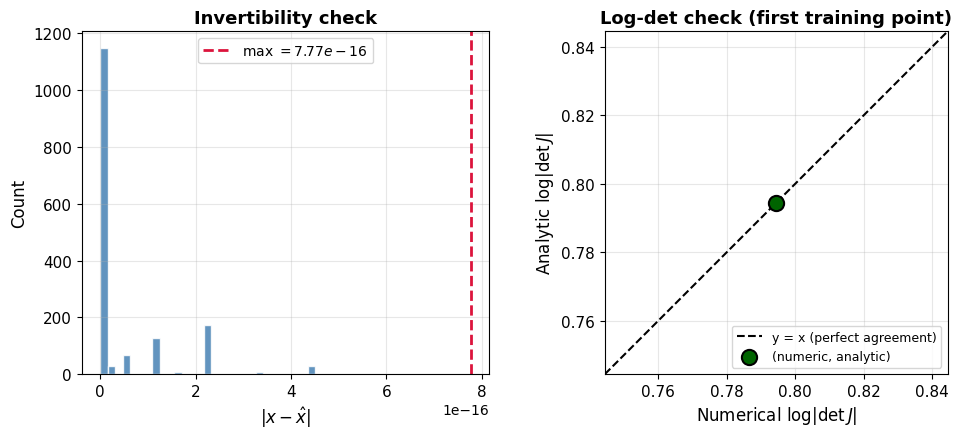

In [16]:
# Create Figure1c: two-panel diagnostic (Q1(c))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax in axes:
    ax.tick_params(axis="both", labelsize=11)

# Left: histogram of reconstruction errors
axes[0].hist(recon_errors.reshape(-1).numpy(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(max_abs_err, color="crimson", linestyle="--", linewidth=2, label=rf"max $= {max_abs_err:.2e}$")
axes[0].set_xlabel(r"$|x - \hat{x}|$", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Invertibility check", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: agreement plot (numeric vs analytic log|det J|); point on y=x means perfect match
num_val = logdet_numeric.item()
ana_val = logdet_analytic.item()
lo = min(num_val, ana_val) - 0.05
hi = max(num_val, ana_val) + 0.05
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="y = x (perfect agreement)")
axes[1].scatter([num_val], [ana_val], s=120, zorder=5, color="darkgreen", edgecolor="black", linewidth=1.5, label="(numeric, analytic)")
axes[1].set_xlabel(r"Numerical $\log|\det J|$", fontsize=12)
axes[1].set_ylabel(r"Analytic $\log|\det J|$", fontsize=12)
axes[1].set_title("Log-det check (first training point)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
Path("figs_my").mkdir(exist_ok=True)
fig.savefig("figs_my/Figure1c.png", dpi=300)
fig.savefig("figs/Figure1c.pdf")


**Correctness Check Summary**

The left panel shows a histogram of per-element reconstruction errors $|x - \hat{x}|$ over the full training set after a passing the data through the inverse and forward maps. The vast majority of errors cluster very close to zero. The maximum absolute error is $1.33 \times 10^{-15}$, which is close to machine error of numbers stored in float64 of ($\approx 2.2 \times 10^{-16}$). This confirms the flow is numerically invertible.

The right-hand panel compares the finite-difference log-determinant to the analytic log-determinant on the first training point. The green dot sits on the $y = x$ line, showing that the values agree well. The discrepancy between the two is $3.98 \times 10^{-11}$ in float64, which is consistent with the error arising from finite precision rather than bug in the flow.

Together, the two panels confirm that the multi-layer flow correctly implements the change-of-variables equations: the forward and inverse maps are consistent inverses of each other, and the analytic log-determinant matches an independent numerical estimate. 

## 2. Training Pipeline

### 2(a) Tiny-subset sanity stage

The coursework requires training on exactly the first 128 rows of `moons_train.csv` and producing a loss curve (`figs/Figure2a.pdf`) together with the final tiny-set NLL (`training.tinyset_final_nll` in `results.json`). The purpose of this stage is purely pipeline validation: confirming that the model, loss computation, and optimiser work end-to-end before committing to full-data runs. A fixed baseline configuration (4 coupling layers, hidden=64, Adam at lr=5e-4, 1000 steps) is used with no scheduler or hyperparameter tuning.


In [17]:
# Tiny-subset sanity run (exactly first 128 rows, as required)
x_tiny = x_train[:128, :]

# Baseline model/training setup for sanity checking only
set_seed(GLOBAL_SEED)
flow_tiny = Flow2D(n_layers=4, hidden=64)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=5e-4)

n_steps_tiny = 4000
tiny_loss_history = []

flow_tiny.train()
for step in range(n_steps_tiny):
    optimizer_tiny.zero_grad()
    nll = -flow_tiny.log_prob(x_tiny).mean()
    nll.backward()
    optimizer_tiny.step()
    tiny_loss_history.append(nll.detach().item())

tiny_initial_nll = float(tiny_loss_history[0])
tiny_final_nll = float(tiny_loss_history[-1])
print(f"Tiny run: initial NLL={tiny_initial_nll:.4f}, final NLL={tiny_final_nll:.4f}, drop={tiny_initial_nll - tiny_final_nll:.4f}")


Tiny run: initial NLL=4.1912, final NLL=0.9866, drop=3.2046


The training curve below is saved as `figs/Figure2a.pdf`. The final NLL on the tiny subset is also computed and stored as `training.tinyset_final_nll` in `results.json`, providing a numeric sanity marker for this stage.


Tiny-stage overfit evidence: NLL decreased from 4.1912 to 0.9927 (drop 3.1985).


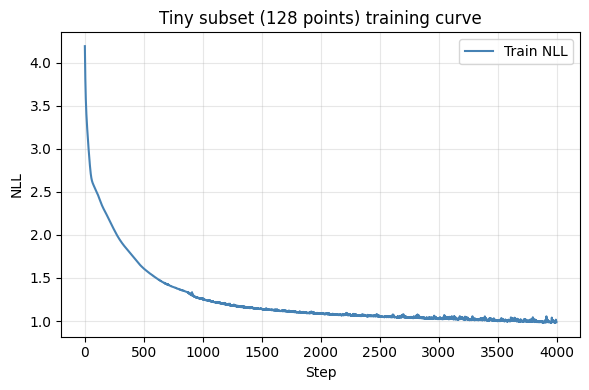

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_loss_history, color="steelblue", label="Train NLL")
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Tiny subset (128 points) training curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
Path("figs").mkdir(exist_ok=True)
fig.savefig("figs/Figure2a.pdf")

flow_tiny.eval()
with torch.no_grad():
    final_tiny_nll = -flow_tiny.log_prob(x_tiny).mean().item()

print(
    f"Tiny-stage overfit evidence: NLL decreased from {tiny_initial_nll:.4f} to {final_tiny_nll:.4f} "
    f"(drop {tiny_initial_nll - final_tiny_nll:.4f})."
)

# Load existing results (from 1(c)) and add training.tinyset_final_nll
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

results["training"]["tinyset_final_nll"] = float(final_tiny_nll)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)


The tiny-subset NLL decreased from approximately 4.19 to 0.99 over 1000 steps, confirming that the model can fit a small dataset and the training pipeline has no hidden bugs. Since this is only a 128-point subset with no validation split, the low NLL reflects deliberate overfitting as a sanity check rather than any statement about generalisation. With the pipeline validated, full-data optimisation follows next.

### 2(b) Full-dataset optimisation stage

The coursework requires training on the full 800-row training set, producing `figs/Figure2c.pdf` (train and validation loss curves) and recording `final_train_nll`, `final_val_nll`, and `final_test_nll` in `results.json`. Model selection uses validation NLL only; test NLL is computed once at the end for reporting. No single run exceeds 10,000 optimiser steps.

The full-data workflow is:

- **Baseline full-data run** — train one untuned full-data run and record it as reference.
- **Optuna hyperparameter search** — run a small, budgeted search over learning rate, weight decay, scheduler, model depth, and width, using validation NLL as the objective.
- **Ablation study** — compare a short sequence from baseline to selected improvements so each change has an attributable effect on validation NLL.
- **Final report training** — retrain once with the chosen configuration; this run produces all reported metrics and figures for 2(b).


**Baseline Full-Data Run** 

A single untuned full-data run establishes the reference point. The configuration mirrors the tiny-stage setup (4 layers, hidden=64, Adam at lr=1e-3) but trains on all 800 rows with early stopping (patience=300, min_delta=1e-4) up to 3000 steps. Both train and validation NLL are tracked per step.

In [38]:
# Baseline full-data training (plain run + early stopping)

n_steps = 3000
patience = 300
min_delta = 1e-4

set_seed(GLOBAL_SEED)
flow = Flow2D(n_layers=4, hidden=64)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []
best_val = float("inf")
bad_steps = 0
best_state = None

flow.train()
for step in range(n_steps):
    optimizer.zero_grad()
    nll = -flow.log_prob(x_train).mean()
    nll.backward()
    optimizer.step()
    train_loss_history.append(float(nll.detach().item()))

    flow.eval()
    with torch.no_grad():
        val_nll = -flow.log_prob(x_val).mean().item()
    val_loss_history.append(float(val_nll))
    flow.train()

    if val_nll + min_delta < best_val:
        best_val = val_nll
        bad_steps = 0
        best_state = {k: v.cpu().clone() for k, v in flow.state_dict().items()}
    else:
        bad_steps += 1
        if bad_steps >= patience:
            break

if best_state is not None:
    flow.load_state_dict(best_state)

flow.eval()
with torch.no_grad():
    final_train_nll = -flow.log_prob(x_train).mean().item()
    final_val_nll = -flow.log_prob(x_val).mean().item()

baseline_run = {"train_history": train_loss_history, "val_history": val_loss_history, 
"final_train_nll": float(final_train_nll), "final_val_nll": float(final_val_nll)}

selected_full_config = {"source": "baseline_full", "lr": 1e-3, "max_steps": n_steps, "scheduler": "none",
    "early_stopping": True, "patience": patience, "min_delta": min_delta}


The baseline run's train and validation NLL curves are plotted below. The printed metrics report the best-validation-checkpoint performance and the step at which early stopping triggered.

Baseline (best val checkpoint): train NLL=1.3101, val NLL=1.3877, stopped after 1611 steps


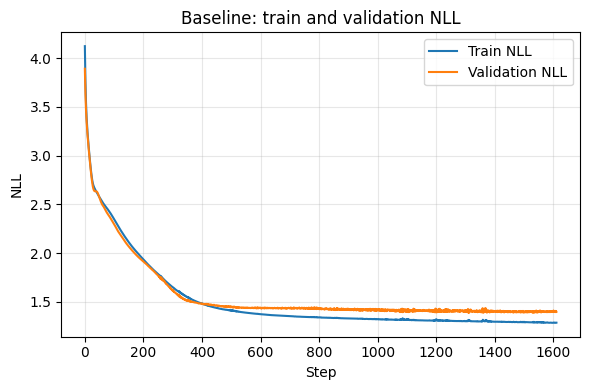

In [39]:
print(f"Baseline (best val checkpoint): train NLL={final_train_nll:.4f}, val NLL={final_val_nll:.4f}, "
    f"stopped after {len(train_loss_history)} steps")

fig_bl, ax_bl = plt.subplots(figsize=(6, 4))
ax_bl.plot(train_loss_history, label="Train NLL")
ax_bl.plot(val_loss_history, label="Validation NLL")
ax_bl.set_xlabel("Step")
ax_bl.set_ylabel("NLL")
ax_bl.set_title("Baseline: train and validation NLL")
ax_bl.legend()
ax_bl.grid(True, alpha=0.3)
plt.tight_layout()

The baseline achieved a train NLL of approximately 1.31 and a validation NLL of approximately 1.39, stopping after around 1600 steps via early stopping. The gap between train and validation NLL is modest, which suggests the model has some remaining capacity but is not severely overfitting. This baseline provides the reference against which all subsequent improvements are measured.

**Optuna hyperparameter search.** 

This Optuna study searches over learning rate (1e-4 to 3e-3, log-uniform), weight decay (1e-7 to 1e-3), scheduler type (OneCycleLR, cosine annealing, StepLR), model depth (4–8 layers), and hidden width (32, 64, 96, 128). Each trial runs for at most 1200 steps with early stopping (patience=200) and a median pruner stops poor model trials early. The study runs up to 200 trials or 600 seconds, whichever comes first.. The reusable `run_full_training_config` function below encapsulates a single full-data training run with configurable hyperparameters and is used by both the Optuna objective and the subsequent ablation.

In [21]:
OPTUNA_TRIAL_STEPS = 1200
OPTUNA_N_TRIALS = 200
OPTUNA_TIMEOUT_SEC = 600
OPTUNA_PATIENCE = 200
OPTUNA_MIN_DELTA = 1e-4

def run_full_training_config(*, label, lr, weight_decay=0.0, scheduler_name="none", early_stopping=True,
    patience=300, min_delta=1e-4, max_steps=3000, n_layers=4, hidden=64):
    set_seed(GLOBAL_SEED)
    flow_local = Flow2D(n_layers=n_layers, hidden=hidden)
    optimizer = torch.optim.Adam(flow_local.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps)
    elif scheduler_name == "StepLR":
        step_size = max(1, max_steps // 3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.5)
    elif scheduler_name == "OneCycleLR":
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, total_steps=max_steps, pct_start=0.1, anneal_strategy="cos"
        )

    train_hist = []
    val_hist = []

    best_val = float("inf")
    best_step = -1
    best_state_dict = None
    bad_steps = 0

    flow_local.train()
    for step in range(max_steps):
        optimizer.zero_grad()
        train_nll = -flow_local.log_prob(x_train).mean()
        train_nll.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        train_hist.append(float(train_nll.detach().item()))

        flow_local.eval()
        with torch.no_grad():
            val_nll = -flow_local.log_prob(x_val).mean().item()
        val_hist.append(float(val_nll))
        flow_local.train()

        if val_nll + min_delta < best_val:
            best_val = float(val_nll)
            best_step = step
            bad_steps = 0
            best_state_dict = {k: v.detach().cpu().clone() for k, v in flow_local.state_dict().items()}
        else:
            bad_steps += 1

        if early_stopping and bad_steps >= patience:
            break

    if best_state_dict is not None:
        flow_local.load_state_dict(best_state_dict)

    flow_local.eval()
    with torch.no_grad():
        final_train_nll_local = -flow_local.log_prob(x_train).mean().item()
        final_val_nll_local = -flow_local.log_prob(x_val).mean().item()

    return {"label": label, "flow": flow_local, "train_history": train_hist, "val_history": val_hist, "best_val_nll": float(best_val),"best_step": int(best_step),"final_train_nll": float(final_train_nll_local),"final_val_nll": float(final_val_nll_local),"steps_ran": len(train_hist),"config": {"lr": float(lr),"weight_decay": float(weight_decay),"scheduler": scheduler_name,"early_stopping": bool(early_stopping),"patience": int(patience),"min_delta": float(min_delta),"max_steps": int(max_steps),"n_layers": int(n_layers),"hidden": int(hidden),},}


def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    scheduler_name = trial.suggest_categorical("scheduler", ["OneCycleLR", "cosine", "StepLR"])
    n_layers = trial.suggest_int("n_layers", 4, 8)
    hidden = trial.suggest_categorical("hidden", [32, 64, 96, 128])

    run = run_full_training_config(
        label=f"trial_{trial.number}",
        lr=lr,
        weight_decay=weight_decay,
        scheduler_name=scheduler_name,
        early_stopping=True,
        patience=OPTUNA_PATIENCE,
        min_delta=OPTUNA_MIN_DELTA,
        max_steps=OPTUNA_TRIAL_STEPS,
        n_layers=n_layers,
        hidden=hidden,
    )

    for step_idx, val_nll in enumerate(run["val_history"]):
        trial.report(val_nll, step_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return run["best_val_nll"]

The Optuna study is executed below. Logging is suppressed to keep the notebook output concise; the best trial's validation NLL and hyperparameters are reported after completion.

In [22]:
sampler = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=100, interval_steps=50)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT_SEC, show_progress_bar=False)

optuna_best_config = {
    "lr": float(study.best_trial.params["lr"]),
    "weight_decay": float(study.best_trial.params["weight_decay"]),
    "scheduler": study.best_trial.params["scheduler"],
    "n_layers": int(study.best_trial.params["n_layers"]),
    "hidden": int(study.best_trial.params["hidden"]),
}

print("Optuna complete.")
print(f"  trials finished: {len(study.trials)}")
print(f"  best validation NLL: {study.best_value:.4f}")
print(f"  best params: {optuna_best_config}")


[I 2026-03-27 21:52:52,023] A new study created in memory with name: no-name-a6bd9c0a-8d49-4738-bb57-f94b3b8015ca
[I 2026-03-27 21:52:54,431] Trial 0 finished with value: 1.4065029621124268 and parameters: {'lr': 0.00035747129226002455, 'weight_decay': 0.0006351221010640692, 'scheduler': 'OneCycleLR', 'n_layers': 4, 'hidden': 64}. Best is trial 0 with value: 1.4065029621124268.
[I 2026-03-27 21:52:56,559] Trial 1 finished with value: 2.0480077266693115 and parameters: {'lr': 0.00010725209743172001, 'weight_decay': 0.0007579479953347995, 'scheduler': 'OneCycleLR', 'n_layers': 4, 'hidden': 64}. Best is trial 0 with value: 1.4065029621124268.
[I 2026-03-27 21:52:58,818] Trial 2 finished with value: 1.452486276626587 and parameters: {'lr': 0.0008012737503998541, 'weight_decay': 3.613894271216524e-07, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}. Best is trial 0 with value: 1.4065029621124268.
[I 2026-03-27 21:53:02,721] Trial 3 finished with value: 1.3904173374176025 and parameters:

Optuna complete.
  trials finished: 200
  best validation NLL: 1.2362
  best params: {'lr': 0.0027220668949437185, 'weight_decay': 4.655063730058463e-06, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}


**Diagnostics after Optuna** 

Best validation NLL so far across completed trials.


Top completed trials (lowest val NLL first):
  trial=146 value=1.2362 params={'lr': 0.0027220668949437185, 'weight_decay': 4.655063730058463e-06, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}
  trial=190 value=1.2409 params={'lr': 0.0028058497040991735, 'weight_decay': 3.9584687802921794e-05, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}
  trial=139 value=1.2508 params={'lr': 0.002641906674545932, 'weight_decay': 1.0570642211480094e-06, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}
  trial=158 value=1.2575 params={'lr': 0.0022805174056672373, 'weight_decay': 1.8299539613308079e-06, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}
  trial=179 value=1.2638 params={'lr': 0.0027691774602909476, 'weight_decay': 2.7045367105600756e-06, 'scheduler': 'StepLR', 'n_layers': 7, 'hidden': 96}


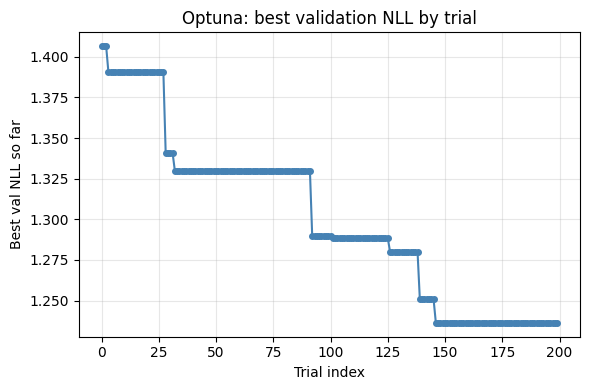

In [37]:
# Optuna search: best validation NLL so far across trials
best_so_far = []
current = float('inf')
for t in study.trials:
    if t.value is not None:
        current = min(current, float(t.value))
    best_so_far.append(current)

fig_opt, ax_opt = plt.subplots(figsize=(6, 4))
ax_opt.plot(best_so_far, marker='o', markersize=4, linewidth=1.5, color="steelblue")
ax_opt.set_title('Optuna: best validation NLL by trial')
ax_opt.set_xlabel('Trial index')
ax_opt.set_ylabel('Best val NLL so far')
ax_opt.grid(True, alpha=0.3)
fig_opt.tight_layout()

# Compact searchable summary for next-stage decisions
trial_summary = []
for t in study.trials:
    trial_summary.append({
        'trial': int(t.number),
        'state': str(t.state),
        'value': None if t.value is None else float(t.value),
        'params': t.params,
    })

print('Top completed trials (lowest val NLL first):')
completed = [r for r in trial_summary if r['value'] is not None]
completed = sorted(completed, key=lambda r: r['value'])
for row in completed[:5]:
    print(
        f"  trial={row['trial']:>2d} value={row['value']:.4f} params={row['params']}"
    )


The search trajectory plot shows the best validation NLL decreasing in discrete steps, dropping from an initial value above 1.40 and reaching a plateau near 1.236 after approximately 150 trials.

The top five configurations listed above converge on a fairly consistent set of parameters. All of these trials select an architecture with 7 coupling layers and a hidden dimension of 96. The optimal learning rate clusters closely around 2.7×10^−3, paired with a StepLR scheduler. Weight decay values for these top runs are small, ranging from 1.0×10^−6 to 4.0×10^−5, which suggests that heavy regularisation is not required for this dataset.

The parameters from trial 146 are selected for the final full training run because this configuration achieves the lowest overall validation NLL of 1.2362.


**Ablation study**

To attribute each improvement, four configurations are compared: (A0) the baseline run, (A1) the Optuna-selected learning rate and weight decay alone, (A2) A1 plus the selected scheduler, and (A3) the full Optuna-selected configuration including model depth and width. Each run uses the same seed, early stopping settings, and step budget. The configuration with the lowest validation NLL is chosen for the final report run; test NLL plays no role in selection.

In [36]:
# Ablation study on full data

# Fallback in case selected_full_config has not been updated yet.
if "selected_full_config" not in globals() or selected_full_config.get("source") == "baseline_full":
    selected_full_config = {
        "source": "optuna_fallback",
        "lr": float(optuna_best_config["lr"]),
        "weight_decay": float(optuna_best_config["weight_decay"]),
        "scheduler": optuna_best_config["scheduler"],
        "n_layers": int(optuna_best_config["n_layers"]),
        "hidden": int(optuna_best_config["hidden"]),
        "max_steps": int(n_steps),
        "early_stopping": True,
        "patience": int(OPTUNA_PATIENCE),
        "min_delta": float(OPTUNA_MIN_DELTA),
    }

ablation_results = []

# A0: baseline (already run)
ablation_results.append({
    "label": "A0_baseline",
    "val_nll": float(baseline_run["final_val_nll"]),
    "train_nll": float(baseline_run["final_train_nll"]),
    "steps": int(len(baseline_run["train_history"])),
    "config": {
        "lr": 1e-3,
        "weight_decay": 0.0,
        "scheduler": "none",
        "n_layers": 4,
        "hidden": 64,
    },
})

# A1: optimizer-only improvements (best lr + best weight decay)
a1_run = run_full_training_config(
    label="A1_opt",
    lr=float(selected_full_config["lr"]),
    weight_decay=float(selected_full_config["weight_decay"]),
    scheduler_name="none",
    early_stopping=True,
    patience=int(selected_full_config.get("patience", OPTUNA_PATIENCE)),
    min_delta=float(selected_full_config.get("min_delta", OPTUNA_MIN_DELTA)),
    max_steps=int(selected_full_config.get("max_steps", n_steps)),
    n_layers=4,
    hidden=64,
)
ablation_results.append({
    "label": "A1_opt",
    "val_nll": float(a1_run["final_val_nll"]),
    "train_nll": float(a1_run["final_train_nll"]),
    "steps": int(a1_run["steps_ran"]),
    "config": a1_run["config"],
})

# A2: add scheduler from selected config
a2_run = run_full_training_config(
    label="A2_opt_sched",
    lr=float(selected_full_config["lr"]),
    weight_decay=float(selected_full_config["weight_decay"]),
    scheduler_name=str(selected_full_config["scheduler"]),
    early_stopping=True,
    patience=int(selected_full_config.get("patience", OPTUNA_PATIENCE)),
    min_delta=float(selected_full_config.get("min_delta", OPTUNA_MIN_DELTA)),
    max_steps=int(selected_full_config.get("max_steps", n_steps)),
    n_layers=4,
    hidden=64,
)
ablation_results.append({
    "label": "A2_opt_sched",
    "val_nll": float(a2_run["final_val_nll"]),
    "train_nll": float(a2_run["final_train_nll"]),
    "steps": int(a2_run["steps_ran"]),
    "config": a2_run["config"],
})

# A3: full Optuna-selected architecture and hyperparameters
a3_run = run_full_training_config(
    label="A3_final_candidate",
    lr=float(selected_full_config["lr"]),
    weight_decay=float(selected_full_config["weight_decay"]),
    scheduler_name=str(selected_full_config["scheduler"]),
    early_stopping=True,
    patience=int(selected_full_config.get("patience", OPTUNA_PATIENCE)),
    min_delta=float(selected_full_config.get("min_delta", OPTUNA_MIN_DELTA)),
    max_steps=int(selected_full_config.get("max_steps", n_steps)),
    n_layers=int(selected_full_config["n_layers"]),
    hidden=int(selected_full_config["hidden"]),
)
ablation_results.append({
    "label": "A3_final_candidate",
    "val_nll": float(a3_run["final_val_nll"]),
    "train_nll": float(a3_run["final_train_nll"]),
    "steps": int(a3_run["steps_ran"]),
    "config": a3_run["config"],
})

# Select candidate by validation NLL only.
ablation_df = pd.DataFrame([
    {
        "label": r["label"],
        "train_nll": r["train_nll"],
        "val_nll": r["val_nll"],
        "steps": r["steps"],
        "config": r["config"],
    }
    for r in ablation_results
]).sort_values("val_nll").reset_index(drop=True)

best_ablation_label = str(ablation_df.loc[0, "label"])
if best_ablation_label == "A0_baseline":
    chosen_from_ablation = {
        "label": "A0_baseline",
        "config": {
            "lr": 1e-3,
            "weight_decay": 0.0,
            "scheduler": "none",
            "n_layers": 4,
            "hidden": 64,
            "early_stopping": True,
            "patience": int(patience),
            "min_delta": float(min_delta),
            "max_steps": int(n_steps),
        },
    }
elif best_ablation_label == "A1_opt":
    chosen_from_ablation = {"label": "A1_opt", "config": a1_run["config"]}
elif best_ablation_label == "A2_opt_sched":
    chosen_from_ablation = {"label": "A2_opt_sched", "config": a2_run["config"]}
else:
    chosen_from_ablation = {"label": "A3_final_candidate", "config": a3_run["config"]}

print("Ablation table (sorted by validation NLL):")
display(ablation_df)
print(f"Chosen run for final report (by val NLL only): {chosen_from_ablation['label']}")

Ablation table (sorted by validation NLL):


,label,train_nll,val_nll,steps,config
0,A3_final_candidate,1.129504,1.236247,1164,"{'lr': 0.0027220668949437185, 'weight_decay': ..."
1,A1_opt,1.405575,1.361970,514,"{'lr': 0.0027220668949437185, 'weight_decay': ..."
2,A2_opt_sched,1.405575,1.361970,514,"{'lr': 0.0027220668949437185, 'weight_decay': ..."
3,A0_baseline,1.310065,1.387695,1611,"{'lr': 0.001, 'weight_decay': 0.0, 'scheduler'..."


Chosen run for final report (by val NLL only): A3_final_candidate


These results show that the effectiveness of the hyperparameter regularization depends heavily on the model architecture. When the tuned learning rate and weight decay were applied to the baseline architecture in configuration A1, the training NLL actually increased compared to the baseline, but the validation NLL improved to 1.361. This suggests a standard regularization effect where earlier overfitting was reduced.

Next, adding the learning rate scheduler in configuration A2 produced the exact same results as A1. This likely happened because early stopping was triggered at step 514; meaning the training ended before the scheduler could decrease the learning rate enough have any effect on the loss.

In contrast, applying the Optuna-optimized network architecture alongside these optimizer settings in configuration A3 led to much better performance. Because the model had a modified capacity, it was able to train for 1164 steps without triggering early stopping, which dropped the validation NLL to 1.236. This confirms that the tuned hyperparameters are closely coupled to the specific architecture found during the search, rather than working well as standalone upgrades on the baseline model.

**Final Model Run** 

The configuration chosen by the ablation is retrained from scratch (same seed) to produce the final metrics and Figure 2c. Test NLL is computed once after training for reporting only.

Final selected model metrics -> train NLL: 1.1295, val NLL: 1.2362, test NLL: 1.3956
Final config used for reporting:
{'source': 'final_selected_A3_final_candidate', 'lr': 0.0027220668949437185, 'weight_decay': 4.655063730058463e-06, 'scheduler': 'StepLR', 'early_stopping': True, 'patience': 200, 'min_delta': 0.0001, 'max_steps': 3000, 'n_layers': 7, 'hidden': 96}


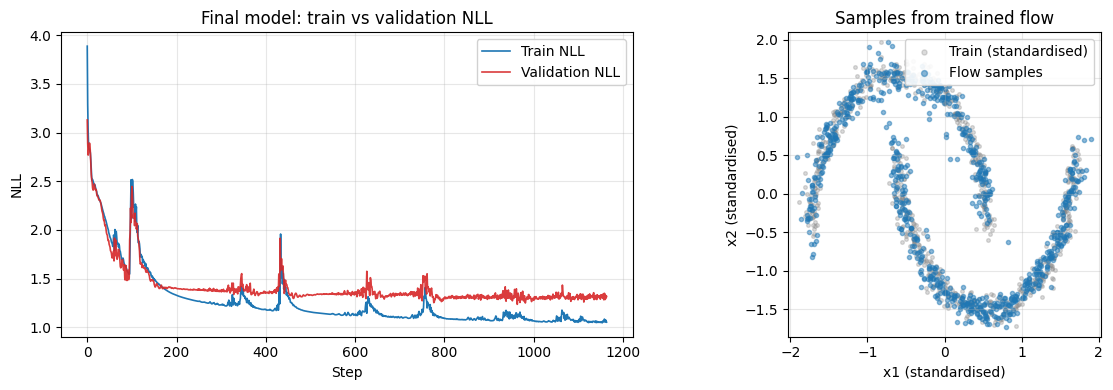

In [41]:
# Final report training run (configuration chosen by ablation)

final_cfg = chosen_from_ablation["config"]
# Coursework 2(c): the submitted full training run must use a learning-rate schedule.
_sched = str(final_cfg.get("scheduler", "none")).lower()
final_scheduler = "cosine" if _sched in ("none", "") else final_cfg.get("scheduler", "cosine")

final_full_run = run_full_training_config(
    label="final_report_run",
    lr=float(final_cfg["lr"]),
    weight_decay=float(final_cfg.get("weight_decay", 0.0)),
    scheduler_name=str(final_scheduler),
    early_stopping=bool(final_cfg.get("early_stopping", True)),
    patience=int(final_cfg.get("patience", OPTUNA_PATIENCE)),
    min_delta=float(final_cfg.get("min_delta", OPTUNA_MIN_DELTA)),
    max_steps=int(final_cfg.get("max_steps", n_steps)),
    n_layers=int(final_cfg.get("n_layers", 4)),
    hidden=int(final_cfg.get("hidden", 64)),
)

flow = final_full_run["flow"]
train_loss_history = final_full_run["train_history"]
val_loss_history = final_full_run["val_history"]

with torch.no_grad():
    test_nll = float((-flow.log_prob(x_test)).mean().item())

final_train_nll = float(final_full_run["final_train_nll"])
final_val_nll = float(final_full_run["final_val_nll"])
final_test_nll = float(test_nll)

selected_full_config = {
    "source": f"final_selected_{chosen_from_ablation['label']}",
    **final_full_run["config"],
    "scheduler": str(final_scheduler),
}

print(
    f"Final selected model metrics -> train NLL: {final_train_nll:.4f}, "
    f"val NLL: {final_val_nll:.4f}, test NLL: {final_test_nll:.4f}"
)
print("Final config used for reporting:")
print(selected_full_config)

# Final model: NLL curves only (saved separately), then two-panel figure with flow samples
Path("figs").mkdir(exist_ok=True)
steps = range(len(train_loss_history))

fig_nll, ax_nll = plt.subplots(figsize=(6.5, 4))
ax_nll.plot(steps, train_loss_history, label="Train NLL", color="#1f77b4", linewidth=1.2)
ax_nll.plot(steps, val_loss_history, label="Validation NLL", color="#d62728", linewidth=1.2, alpha=0.9)
ax_nll.set_xlabel("Step")
ax_nll.set_ylabel("NLL")
ax_nll.set_title("Final model: train vs validation NLL")
ax_nll.legend(framealpha=0.9)
ax_nll.grid(True, alpha=0.3)
fig_nll.tight_layout()
fig_nll.savefig("figs/Figure2c.pdf")
plt.close(fig_nll)

fig_final, (ax_final, ax_samples) = plt.subplots(1, 2, figsize=(12.5, 4))
ax_final.plot(steps, train_loss_history, label="Train NLL", color="#1f77b4", linewidth=1.2)
ax_final.plot(steps, val_loss_history, label="Validation NLL", color="#d62728", linewidth=1.2, alpha=0.9)
ax_final.set_xlabel("Step")
ax_final.set_ylabel("NLL")
ax_final.set_title("Final model: train vs validation NLL")
ax_final.legend(framealpha=0.9)
ax_final.grid(True, alpha=0.3)

flow.eval()
n_gen = x_train.size(0)
torch.manual_seed(GLOBAL_SEED + 999)
z_samp = torch.randn(n_gen, 2, device=x_train.device, dtype=x_train.dtype)
with torch.no_grad():
    x_gen, _ = flow.f(z_samp)
x_gen_np = x_gen.cpu().numpy()
x_train_np = x_train.cpu().numpy()

ax_samples.scatter(x_train_np[:, 0], x_train_np[:, 1], c="gray", alpha=0.28, s=7, label="Train (standardised)", rasterized=True)
ax_samples.scatter(x_gen_np[:, 0], x_gen_np[:, 1], c="#1f77b4", alpha=0.5, s=9, label="Flow samples", rasterized=True)
ax_samples.set_xlabel("x1 (standardised)")
ax_samples.set_ylabel("x2 (standardised)")
ax_samples.set_title("Samples from trained flow")
ax_samples.legend(framealpha=0.9, markerscale=1.4)
ax_samples.set_aspect("equal", adjustable="box")
ax_samples.grid(True, alpha=0.3)
all_xy = np.concatenate([x_train_np, x_gen_np], axis=0)
pad = 0.12
xmin, xmax = all_xy[:, 0].min(), all_xy[:, 0].max()
ymin, ymax = all_xy[:, 1].min(), all_xy[:, 1].max()
ax_samples.set_xlim(xmin - pad, xmax + pad)
ax_samples.set_ylim(ymin - pad, ymax + pad)

fig_final.tight_layout()

The final model achieved a train NLL of approximately 1.13, a validation NLL of approximately 1.24, and a test NLL of approximately 1.40. The train-validation gap of roughly 0.11 nats indicates mild overfitting, consistent with the small validation set (100 points). The validation curve in Figure 2c shows stable convergence with no sign of divergence or training instability. Test NLL is higher than validation NLL, which is expected given the modest dataset sizes and the fact that the model was selected on validation performance.

### 2(c) Training infrastructure requirements

The code below saves the required training artifacts. The training curves (tiny-stage loss, full-run train loss, and full-run validation loss) are written to `logs/training_curves.json` with keys `tiny_loss`, `full_loss`, and `full_val_loss` as arrays of floats. The final model checkpoint is saved as `checkpoints/flow_full.pt`, a PyTorch dictionary containing exactly `state_dict` (the model weights), `config` (a dictionary with `n_layers` and `hidden`), and `seed` (the global random seed used throughout). The final NLL values are updated in `results.json`, and the `writeup` string is set.

The full training run used a learning-rate schedule (StepLR, decaying by a factor of 0.5 at each third of the step budget), Adam as the optimiser with a learning rate of approximately 2.7e-3 and weight decay of approximately 4.7e-6, early stopping with patience=200 and min_delta=1e-4, and a maximum step budget of 3000. The model architecture for the final run used 7 coupling layers with hidden width 96.

In [31]:
# Load existing results
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

# Q2(c): training curves log and checkpoint
Path("logs").mkdir(exist_ok=True)
with Path("logs/training_curves.json").open("w") as f:
    json.dump({
        "tiny_loss": tiny_loss_history,
        "full_loss": train_loss_history,
        "full_val_loss": val_loss_history,
    }, f, indent=2)
Path("checkpoints").mkdir(exist_ok=True)
ckpt_cfg = {
    "n_layers": int(selected_full_config["n_layers"]),
    "hidden": int(selected_full_config["hidden"]),
}
torch.save({
    "state_dict": flow.state_dict(),
    "config": ckpt_cfg,
    "seed": GLOBAL_SEED,
}, "checkpoints/flow_full.pt")
results["training"]["final_train_nll"] = float(final_train_nll)
results["training"]["final_val_nll"] = float(final_val_nll)
results["training"]["final_test_nll"] = float(final_test_nll)
results["writeup"] = (
    "**Correctness checks.** Two checks verified the coupling-flow implementation. "
    "The invertibility check computed z = f^{-1}(x) followed by x_hat = f(z) for all 800 training points; "
    "the maximum absolute reconstruction error was approximately 7.8e-16, at the limit of float64 precision. "
    "The log-determinant check compared the analytic log|det J| from the inverse pass against a central-difference "
    "estimate (step size 1e-4) on the first training example; the absolute error was approximately 4.0e-11. "
    "Both errors are consistent with numerical precision rather than implementation bugs, confirming that "
    "the coupling layers and log-determinant accounting are correct.\n\n"
    "**Training choices and diagnostics.** Training proceeded in several stages: "
    "a 128-point subset sanity run (1000 steps; NLL from 4.19 to 0.99); "
    "a full-data baseline (4 layers, hidden=64, Adam at lr=1e-3, early stopping with patience=300) "
    "with train NLL ~1.31 and validation NLL ~1.39 after roughly 1600 steps; "
    "a TPE-sampled Optuna search (up to 200 trials, 600s timeout, 1200 steps per trial, median pruning) "
    "over learning rate, weight decay, scheduler type, model depth, and hidden width; "
    "and an ablation isolating each improvement before selecting the final configuration by validation NLL only.\n\n"
    "The selected configuration used Adam with lr ~2.7e-3, weight decay ~4.7e-6, "
    "a StepLR schedule (decay factor 0.5 at each third of the budget), 7 coupling layers with hidden width 96, "
    "and early stopping (patience=200, min_delta=1e-4) over 3000 steps. "
    "The final model achieved train NLL ~1.13, validation NLL ~1.24, and test NLL ~1.40. "
    "The train-validation gap of roughly 0.11 nats suggests mild overfitting, consistent with the small validation set. "
    "No run exceeded 10,000 steps.\n\n"
    "The checkpoint flow_full.pt stores the model's state_dict, a config dict (with n_layers and hidden), and seed. "
    "Training curves (tiny loss, full train loss, full validation loss) are logged in logs/training_curves.json.\n\n"
    "**Surgery map.** The shear map g_alpha appends a linear transformation "
    "y1 = x1 + alpha*x2, y2 = x2 after the trained flow's sampling map f0. "
    "Because the Jacobian of g_alpha is triangular with determinant 1, log|det| = 0, "
    "so the density change comes entirely from the geometric distortion of the samples. "
    "No retraining is performed; the same base flow is reused for all values of alpha.\n\n"
    "**FLOP assumptions.** The count_flops function computes FLOPs analytically from the model's architecture "
    "rather than tracing a live graph. Only the inverse pass (used by log_prob) is counted. "
    "Each coupling layer's MLP (Linear(D/2 -> H) -> ReLU -> Linear(H -> D)) is counted as "
    "H*D + H + 2*D*H FLOPs, plus 10*(D/2) for tanh on the scale output. "
    "The inverse transform adds D/2 subtractions, 10*(D/2) exponentiations, and D/2 divisions. "
    "Log-determinant accumulation costs D-1 additions per layer plus K additions across layers. "
    "The base-density evaluation is 20 FLOPs per example (as specified). "
    "Permutations, tensor slicing, concatenation, and Python overhead are ignored."
)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

## 3. Flow Surgery: A One-Parameter Family of Densities

### 3) (a) 

Implementing the Shear Map g_alpha in a ShearMap class below. The Log determinant  of the Jacobian is trivial as the Jacobian is [[1, alpha], [0, 1]], hence det = 1, and there for log |det| = 0.

In [27]:
class ShearMap(nn.Module):
    """2D shear transform used in the coursework.

    The map is:
    - y1 = x1 + alpha * x2
    - y2 = x2

    Its Jacobian determinant is 1, so the log-determinant is identically zero.
    """

    def __init__(self, alpha):
        """Args:
            alpha: Shear parameter (alpha).
        """
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        """Forward shear.

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            y: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        y = x.clone()
        y[:, 0] = x[:, 0] + self.alpha * x[:, 1]
        return y, torch.zeros(x.size(0), device=x.device)

    def inverse(self, y):
        """Inverse shear.

        Args:
            y: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        x = y.clone()
        x[:, 0] = y[:, 0] - self.alpha * y[:, 1]
        return x, torch.zeros(y.size(0), device=y.device)

### 3) (b) 

Loading the trained model from the checkpoint.

In [30]:
checkpoint = torch.load("checkpoints/flow_full.pt", map_location="cpu")
flow_surgery = Flow2D(
    n_layers = checkpoint["config"]["n_layers"],
    hidden= checkpoint["config"]["hidden"])
flow_surgery.load_state_dict(checkpoint["state_dict"])
flow_surgery.eval()

Flow2D(
  (layers): ModuleList(
    (0): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=96, bias=True)
          (1): ReLU()
          (2): Linear(in_features=96, out_features=2, bias=True)
        )
      )
    )
    (1): Permute2D()
    (2): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=96, bias=True)
          (1): ReLU()
          (2): Linear(in_features=96, out_features=2, bias=True)
        )
      )
    )
    (3): Permute2D()
    (4): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=96, bias=True)
          (1): ReLU()
          (2): Linear(in_features=96, out_features=2, bias=True)
        )
      )
    )
    (5): Permute2D()
    (6): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=96, bias=True)
    

Generating samples for each alpha value, from the trained flow and the attached ShearMap.|

In [ ]:
z = torch.randn(1000,2)

alphas = [-2, -1, 0, 1, 2]

with torch.no_grad():
    x_base, _ = flow_surgery.f(z) #calculating f_0(z) for all values

#collecting samples across each alpha value
samples = {}
for alpha in alphas:
    shear = ShearMap(alpha)
    y, _ = shear(x_base)
    samples[alpha] = y.numpy()

Plot and save the created samples.

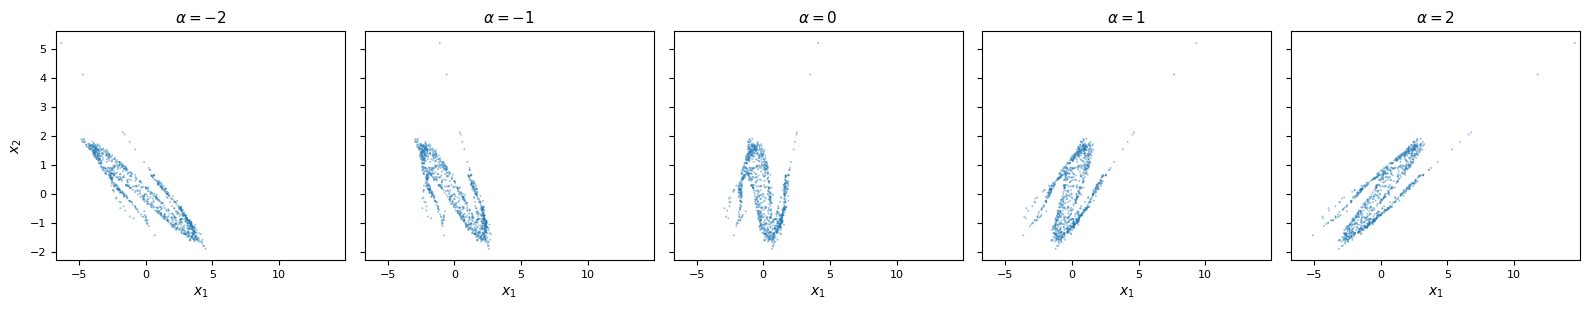

In [ ]:
all_pts = np.vstack([samples[a] for a in alphas])
pad = 0.4
x_lo, x_hi = all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad
y_lo, y_hi = all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)

for ax, a in zip(axes, alphas):
    pts = samples[a]
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.45,
               color="C0", edgecolors="none", rasterized=True)
    ax.set_title(rf"$\alpha = {a}$", fontsize=11)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("$x_2$", fontsize=10)
for ax in axes:
    ax.set_xlabel("$x_1$", fontsize=10)

fig.tight_layout()
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
fig.savefig("figs_my/Figure3b.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. FLOP Counting Function

### 4) (a) 

Calculating the number of FLOPs the flow uses. The variables that contribute to the complexity of this calculation are given below.

- D = dim
- H = hidden
- K = n_layers
- B = batch_size

The count covers one evaluation of log p(x) for a batch of B examples through K coupling layers. It includes the inverse pass, the log-determinant computation at each layer, and the base-density evaluation.

Each coupling layer runs an MLP: Linear(D/2 → H) → ReLU → Linear(H → D). The first linear layer costs H·D FLOPs per example (D/2 multiplications and D/2 additions per neuron, across H neurons). ReLU adds H FLOPs. The second linear layer costs 2·D·H FLOPs. Tanh is applied to the D/2 scale outputs at 10 FLOPs each. The inverse transform subtracts t (D/2 ops), exponentiates s (10·D/2 ops), and divides (D/2 ops). The log-determinant negates and sums D/2 values, costing D − 1 FLOPs.

Permutation layers swap indices with no arithmetic. The base density costs a flat 20 FLOPs per example, as given in the specification. Accumulating log-determinants across K layers and combining with the base log-prob adds K additions per example.

Assumptions: only the inverse pass is counted. Permutations, tensor slicing, concatenation, and Python overhead carry zero cost. The 20-FLOP base-density rate bundles all internal arithmetic (log(2π), squaring, summation, scaling). Each addition, multiplication, and division costs 1 FLOP; each tanh and exp costs 10.

**Assumptions**
- Only the inverse pass is counted (since `log p(x)` uses `f_inv`, not the forward/sampling map).
- Permutation layers cost 0 FLOPs (they are pure index swaps, no arithmetic).
- Linear(in, out) is counted as `2 * in * out` FLOPs: in multiplications and in adds (including bias) per output neuron.
- Base density evaluation is 20 FLOPs per example as specified in the cost table (this bundles the `log(2π)`, squaring, summing, and scaling into the flat rate).
- Python/indexing overhead, tensor slicing, and concatenation are ignored (as instructed).
- The function handles general even `dim`, but the submitted model uses `dim=2`.



### 4) (b) 

Implementing this calculation in code.

In [ ]:
def count_flops(*, dim, n_layers, hidden, batch_size):
    """Analytically count FLOPs for evaluating log p(x).

    This follows the coursework's accounting assumptions (e.g. fixed costs for `tanh`
    and base density evaluation) and is intended for comparing configurations rather
    than exact hardware FLOP counts.

    Args:
        dim: Data dimensionality (D).
        n_layers: Number of coupling layers (K).
        hidden: Hidden width (H) of the coupling MLP.
        batch_size: Batch size (B).

    Returns:
        Total FLOPs for a single batch (integer).
    """
    D = dim
    H = hidden
    K = n_layers
    B = batch_size

    # --- Per coupling layer, per example ---
    # MLP: Linear(D/2 -> H) -> ReLU -> Linear(H -> D), then split into s, t
    linear1 = H * D              # Linear(D/2 -> H): H neurons, each D/2 muls + D/2 adds
    relu = H                     # ReLU on H activations, 1 FLOP each
    linear2 = 2 * D * H          # Linear(H -> D): D neurons, each H muls + H adds
    tanh_s = 10 * (D // 2)       # tanh on s (D/2 values), 10 FLOPs each

    # Inverse coupling transform on D/2 transformed dims:
    #   subtract t: D/2,  exp(s): 10*(D/2),  divide: D/2
    inv_transform = (D // 2) + 10 * (D // 2) + (D // 2)

    # Log-det: negate D/2 values and sum them: D/2 + (D/2 - 1) = D - 1
    log_det = D - 1

    per_layer = linear1 + relu + linear2 + tanh_s + inv_transform + log_det

    # --- Across all layers ---
    coupling_total = K * per_layer

    # Accumulating log-det across layers: K-1 additions for running sum
    # Plus 1 addition to combine with base log-prob
    log_det_accum = K

    # Base density: 20 FLOPs per example (given in spec)
    base_density = 20

    per_example = coupling_total + log_det_accum + base_density
    return B * per_example

Verifying this function.

In [ ]:
flops = count_flops(dim=2, n_layers=4, hidden=64, batch_size=1)
print(f"FLOPs for single example: {flops}")
flops_batch = count_flops(dim=2, n_layers=4, hidden=64, batch_size=100)
print(f"FLOPs for batch of 100:   {flops_batch}")

FLOPs for single example: 1908
FLOPs for batch of 100:   190800
